# 01 — ESCO Skills EDA

**ESCO** (European Skills, Competences, Qualifications and Occupations) is the EU's
multilingual classification of ~13,900 occupational skills. This project uses ESCO skill
labels as a canonical normalisation target so that skill phrases extracted from job adverts
and CVs can be compared on a common vocabulary.

The repository ships a **committed stub index of 67 skills** (a representative sample)
so all tests and notebooks run without downloading anything. The full 13.9 k-skill index
can be built locally by running:

```bash
python scripts/build_esco_index.py
```

which downloads the ESCO CSV from the EU Open Data Portal, encodes all skill labels with
`BAAI/bge-small-en-v1.5`, and writes the two artefacts checked in here:
- `data/esco/skills.parquet` — label + URI metadata
- `data/esco/skill_embeddings.npy` — (N, 384) unit-normalised float32 embeddings

In [1]:
# fmt: off
import os, sys
from pathlib import Path

_cwd = Path.cwd()
_root = next(
    (p for p in [_cwd] + list(_cwd.parents)
     if (p / 'requirements.txt').exists() and (p / 'src').is_dir()),
    None,
)
assert _root, f'Could not find project root from {_cwd}. Open the notebook from inside the project tree.'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')
# fmt: on


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\career-gap-agent


## 1. Load the skills parquet

In [2]:
import pandas as pd

skills = pd.read_parquet('data/esco/skills.parquet')
print(f'Skill count: {len(skills)}')
skills.head(10)

Skill count: 67


,conceptUri,preferredLabel
0,stub:0,python (computer programming)
1,stub:1,sql
2,stub:2,r (programming language)
3,stub:3,java (computer programming)
4,stub:4,scala (programming language)
5,stub:5,machine learning
6,stub:6,deep learning
7,stub:7,natural language processing
8,stub:8,computer vision
9,stub:9,statistics


## 2. Inspect the embedding array

In [3]:
import numpy as np

embs = np.load('data/esco/skill_embeddings.npy')
print(f'Shape: {embs.shape}  dtype: {embs.dtype}')

# Confirm unit-norm (each row should have L2 norm ≈ 1.0)
norms = np.linalg.norm(embs, axis=1)
print(f'Norm stats — min: {norms.min():.6f}  max: {norms.max():.6f}  mean: {norms.mean():.6f}')
assert np.allclose(norms, 1.0, atol=1e-4), 'Embeddings are not unit-normalised!'
print('All rows are unit-normalised.')

Shape: (67, 384)  dtype: float32
Norm stats — min: 1.000000  max: 1.000000  mean: 1.000000
All rows are unit-normalised.


## 3. Visualisation

Two quick plots:
1. Distribution of skill-label character lengths.
2. 2-D PCA projection of the 67 embeddings, with a handful of labels annotated.

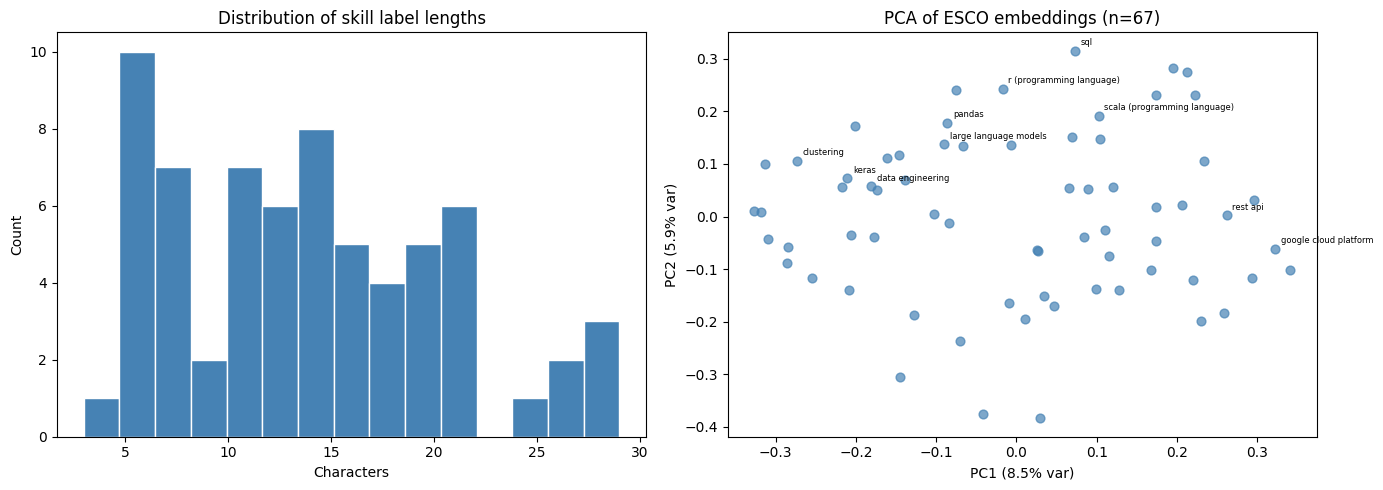

Plot saved to notebooks/esco_eda.png


In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

labels = skills['preferredLabel'].tolist()
label_lengths = [len(l) for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: label-length distribution ──────────────────────────
axes[0].hist(label_lengths, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of skill label lengths')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

# ── Plot 2: 2-D PCA scatter ─────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embs)

axes[1].scatter(coords[:, 0], coords[:, 1], alpha=0.7, color='steelblue', s=40)
axes[1].set_title(f'PCA of ESCO embeddings (n={len(labels)})')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

# Annotate a sample of labels
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(labels), size=min(10, len(labels)), replace=False)
for i in sample_idx:
    axes[1].annotate(
        labels[i], xy=coords[i], fontsize=6,
        xytext=(4, 4), textcoords='offset points',
    )

plt.tight_layout()
plt.savefig('notebooks/esco_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved to notebooks/esco_eda.png')